In [ ]:
!pip install datasets huggingface_hub

In [ ]:
from datasets import load_dataset

# Load the Falah/Alzheimer_MRI dataset as a DatasetDict
data_dict = load_dataset('Falah/Alzheimer_MRI')

# Print available splits in the dataset
print("Available splits:", data_dict.keys())

Available splits: dict_keys(['train', 'test'])


In [ ]:
from datasets import load_dataset
import pandas as pd

# Load the train split
train_dataset = load_dataset('Falah/Alzheimer_MRI', split='train')

# Load the test split
test_dataset = load_dataset('Falah/Alzheimer_MRI', split='test')

# Convert to pandas DataFrames
train_df = train_dataset.to_pandas()
test_df = test_dataset.to_pandas()

# Combine both DataFrames
combined_dataset = pd.concat([train_df, test_df], ignore_index=True)

print(f"Combined dataset shape: {combined_dataset.shape}")
print("First 5 rows of combined dataset:")
display(combined_dataset.head())

Combined dataset shape: (6400, 2)
First 5 rows of combined dataset:


,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,2


In [ ]:
print("Class-wise counts for combined dataset:")
label_counts = combined_dataset['label'].value_counts().sort_index()
display(label_counts)

Class-wise counts for combined dataset:


,count
label,
0,896
1,64
2,3200
3,2240


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import math
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import keras
from tensorflow import keras
from keras import Sequential
from keras import layers
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Activation, BatchNormalization, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams['figure.dpi'] = 300
colors = ["#B6EE56", "#D85F9C", "#EEA756", "#56EEE8"]

In [ ]:
try:
    if tf.test.gpu_device_name():
        physical_devices = tf.config.experimental.list_physical_devices('GPU')
        print('GPU active! -', physical_devices)
    else:
        print('GPU not active!')
except Exception as e:
    print('An error occurred while checking the GPU:', e)

GPU not active!


The `image_counter` function was designed to work with a directory structure, but since the dataset was loaded directly into memory and combined, we can generate the same class distribution plot using the `label_counts` variable we already computed earlier.

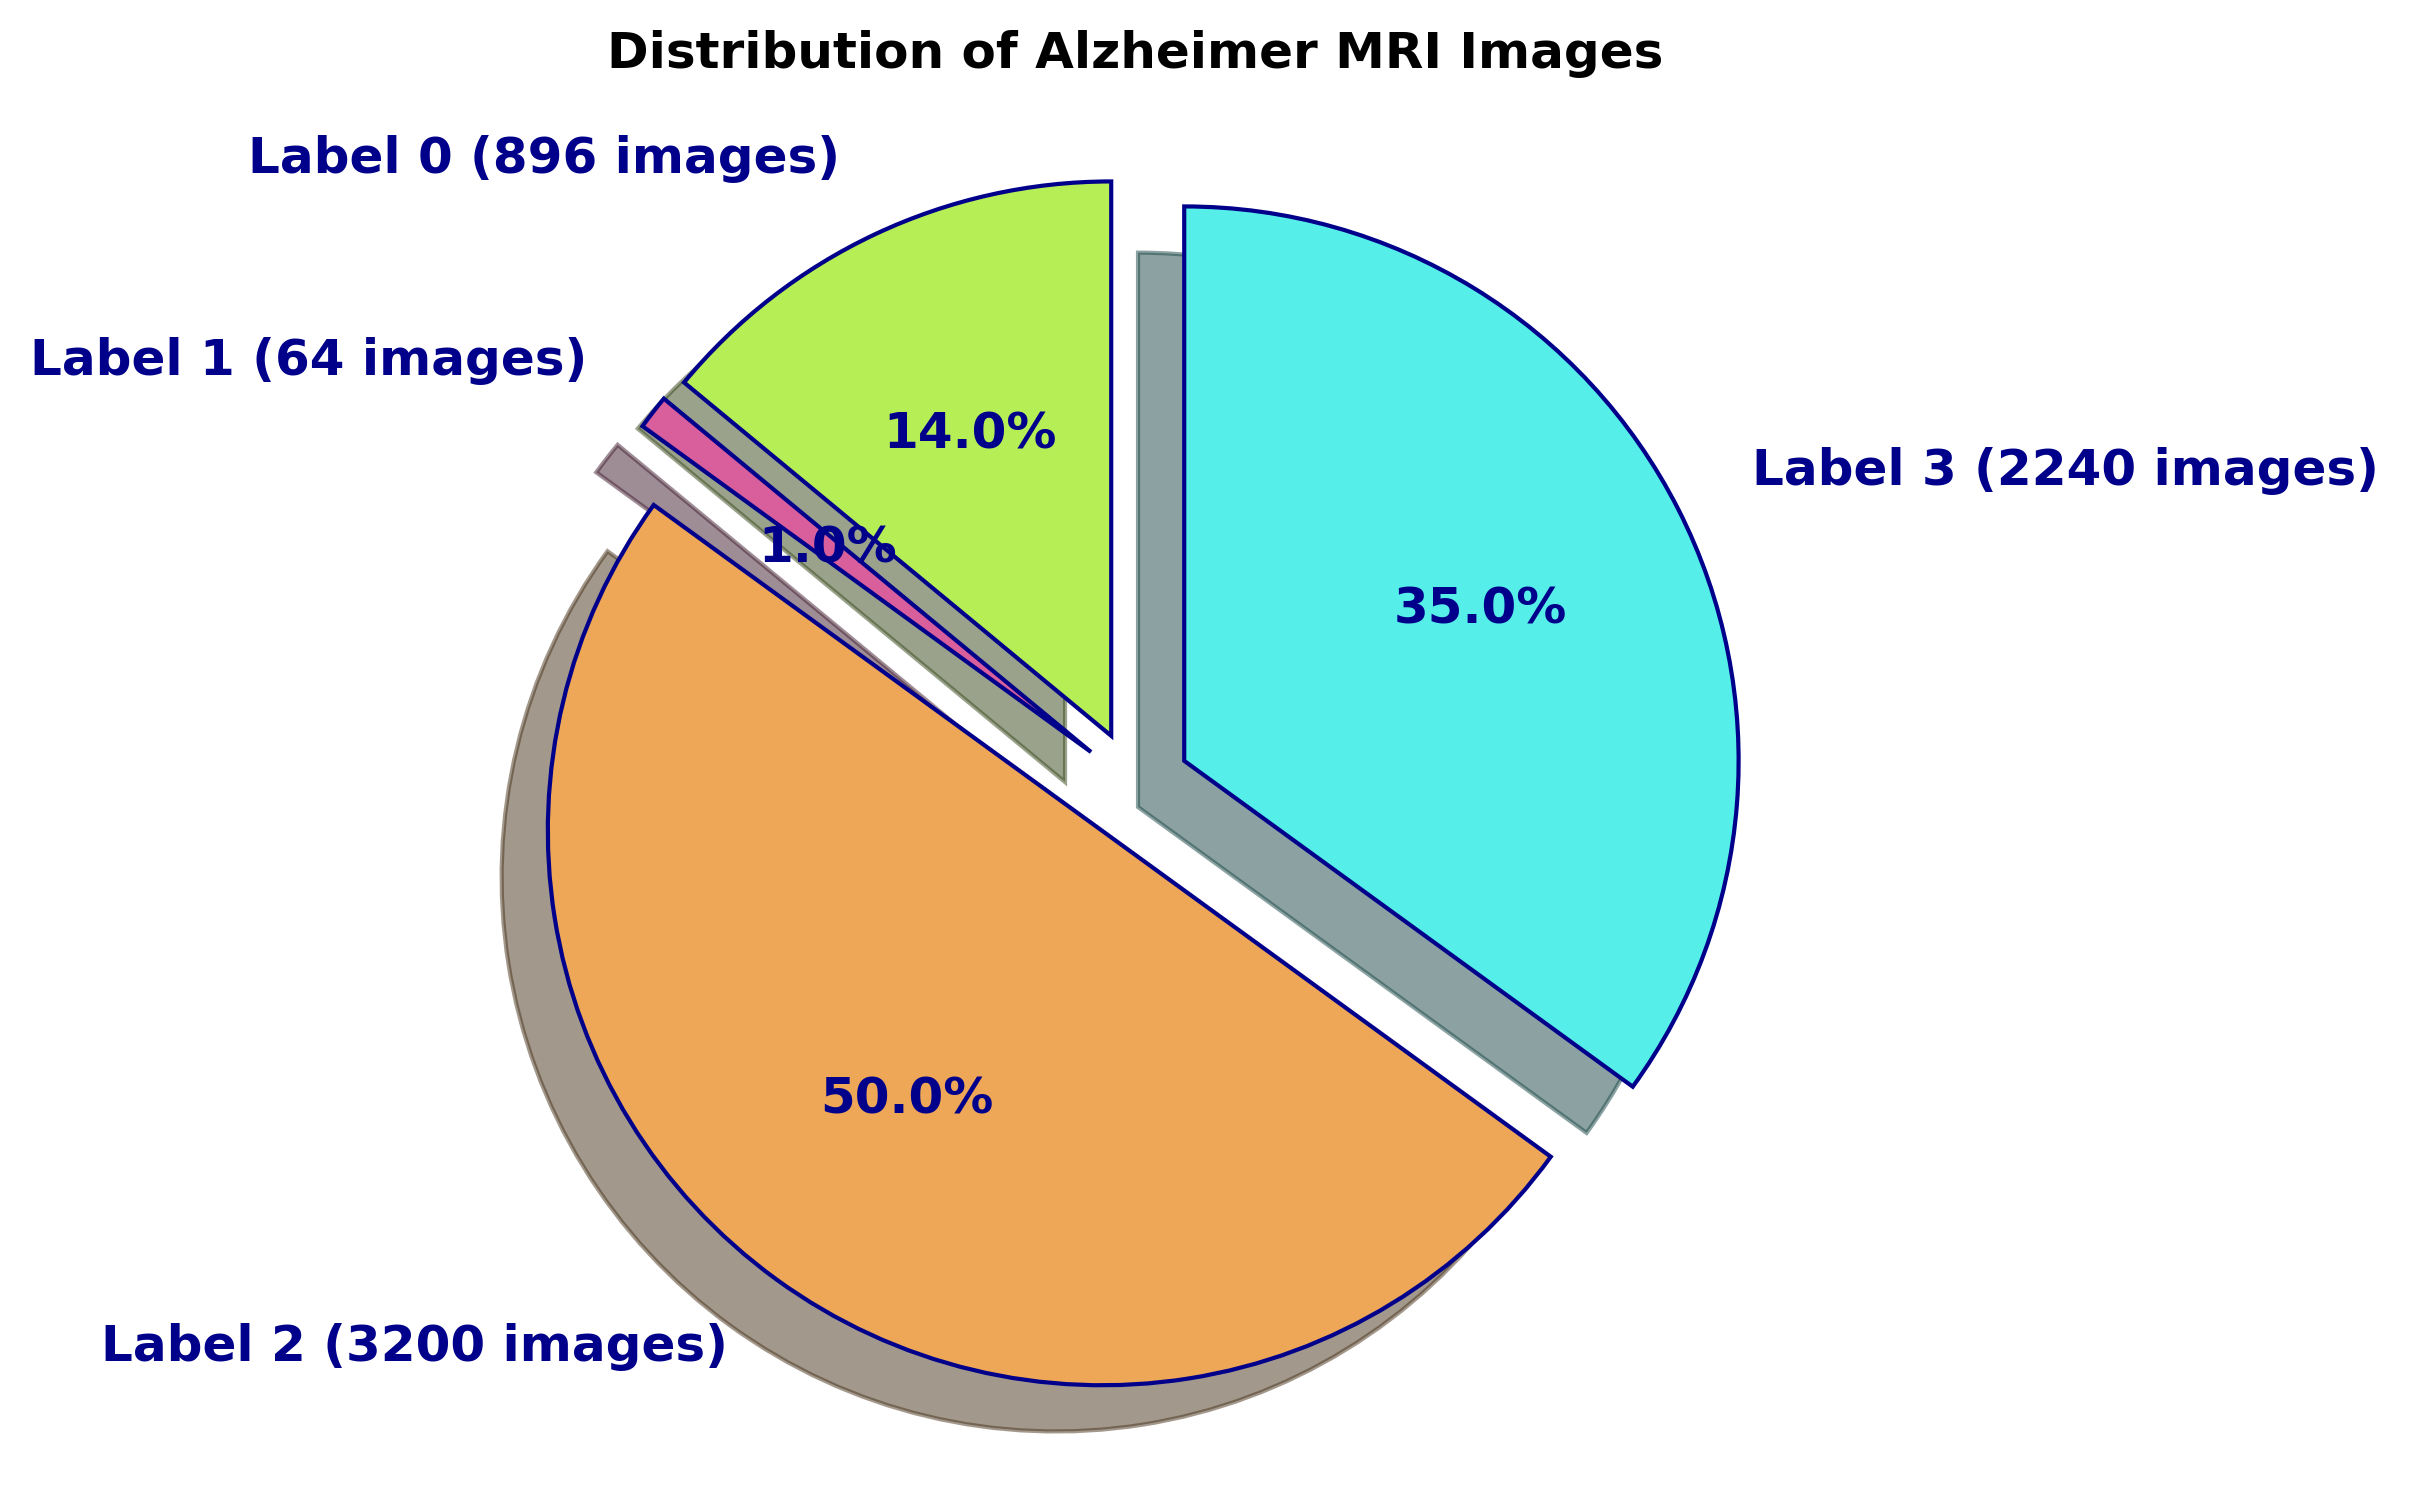

In [ ]:
import matplotlib.pyplot as plt

# Assuming label_counts and colors are already defined in the environment
# label_counts: Series containing class counts
# colors: List of colors for the pie chart

keys = label_counts.index.astype(str).tolist()
values = label_counts.values.tolist()

# Ensure explode has the correct length
explode = [0.1] * len(keys)

labels = [f'Label {key} ({value} images)' for key, value in zip(keys, values)]

plt.figure(figsize=(10, 6), dpi=300)
plt.pie(values, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold', 'color': 'darkblue'},
        wedgeprops={'edgecolor': 'darkblue'}, labeldistance=1.15)
plt.title('Distribution of Alzheimer MRI Images', size=12, fontweight='bold')
plt.show()

In [ ]:
import tensorflow as tf
import numpy as np

# Define image size
IMAGE_SIZE = (128, 128)

def decode_img(img_bytes):
    # Decode the image bytes to a tensor
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    # Resize the image
    img = tf.image.resize(img, IMAGE_SIZE)
    # Normalize the pixel values
    img = img / 255.0  # Normalize to [0, 1]
    return img

def process_path(img_bytes, label):
    # img_bytes is now directly the raw byte string tensor
    img = decode_img(img_bytes)
    return img, label

# Convert combined_dataset to numpy arrays for easier processing
# Extract raw byte strings from the dictionaries
image_bytes_list = [item['bytes'] for item in combined_dataset['image'].to_numpy()]
raw_image_bytes_array = np.array(image_bytes_list, dtype=object)
labels_array = combined_dataset['label'].to_numpy().astype(int)

# Create a tf.data.Dataset from slices of the numpy arrays (raw bytes and labels)
dataset = tf.data.Dataset.from_tensor_slices((raw_image_bytes_array, labels_array))

# Apply the processing function to each element in the dataset
dataset = dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Shuffle and batch the dataset
BATCH_SIZE = 32
dataset = dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Get class names from label_counts (assuming 0-indexed labels)
class_names = [str(i) for i in sorted(combined_dataset['label'].unique())]

print(f"Created tf.data.Dataset with {len(class_names)} classes: {class_names}")
print("Example batch shapes:")
for images, labels in dataset.take(1):
    print(f"  Images shape: {images.shape}")
    print(f"  Labels shape: {labels.shape}")

Created tf.data.Dataset with 4 classes: ['0', '1', '2', '3']
Example batch shapes:
  Images shape: (32, 128, 128, 3)
  Labels shape: (32,)


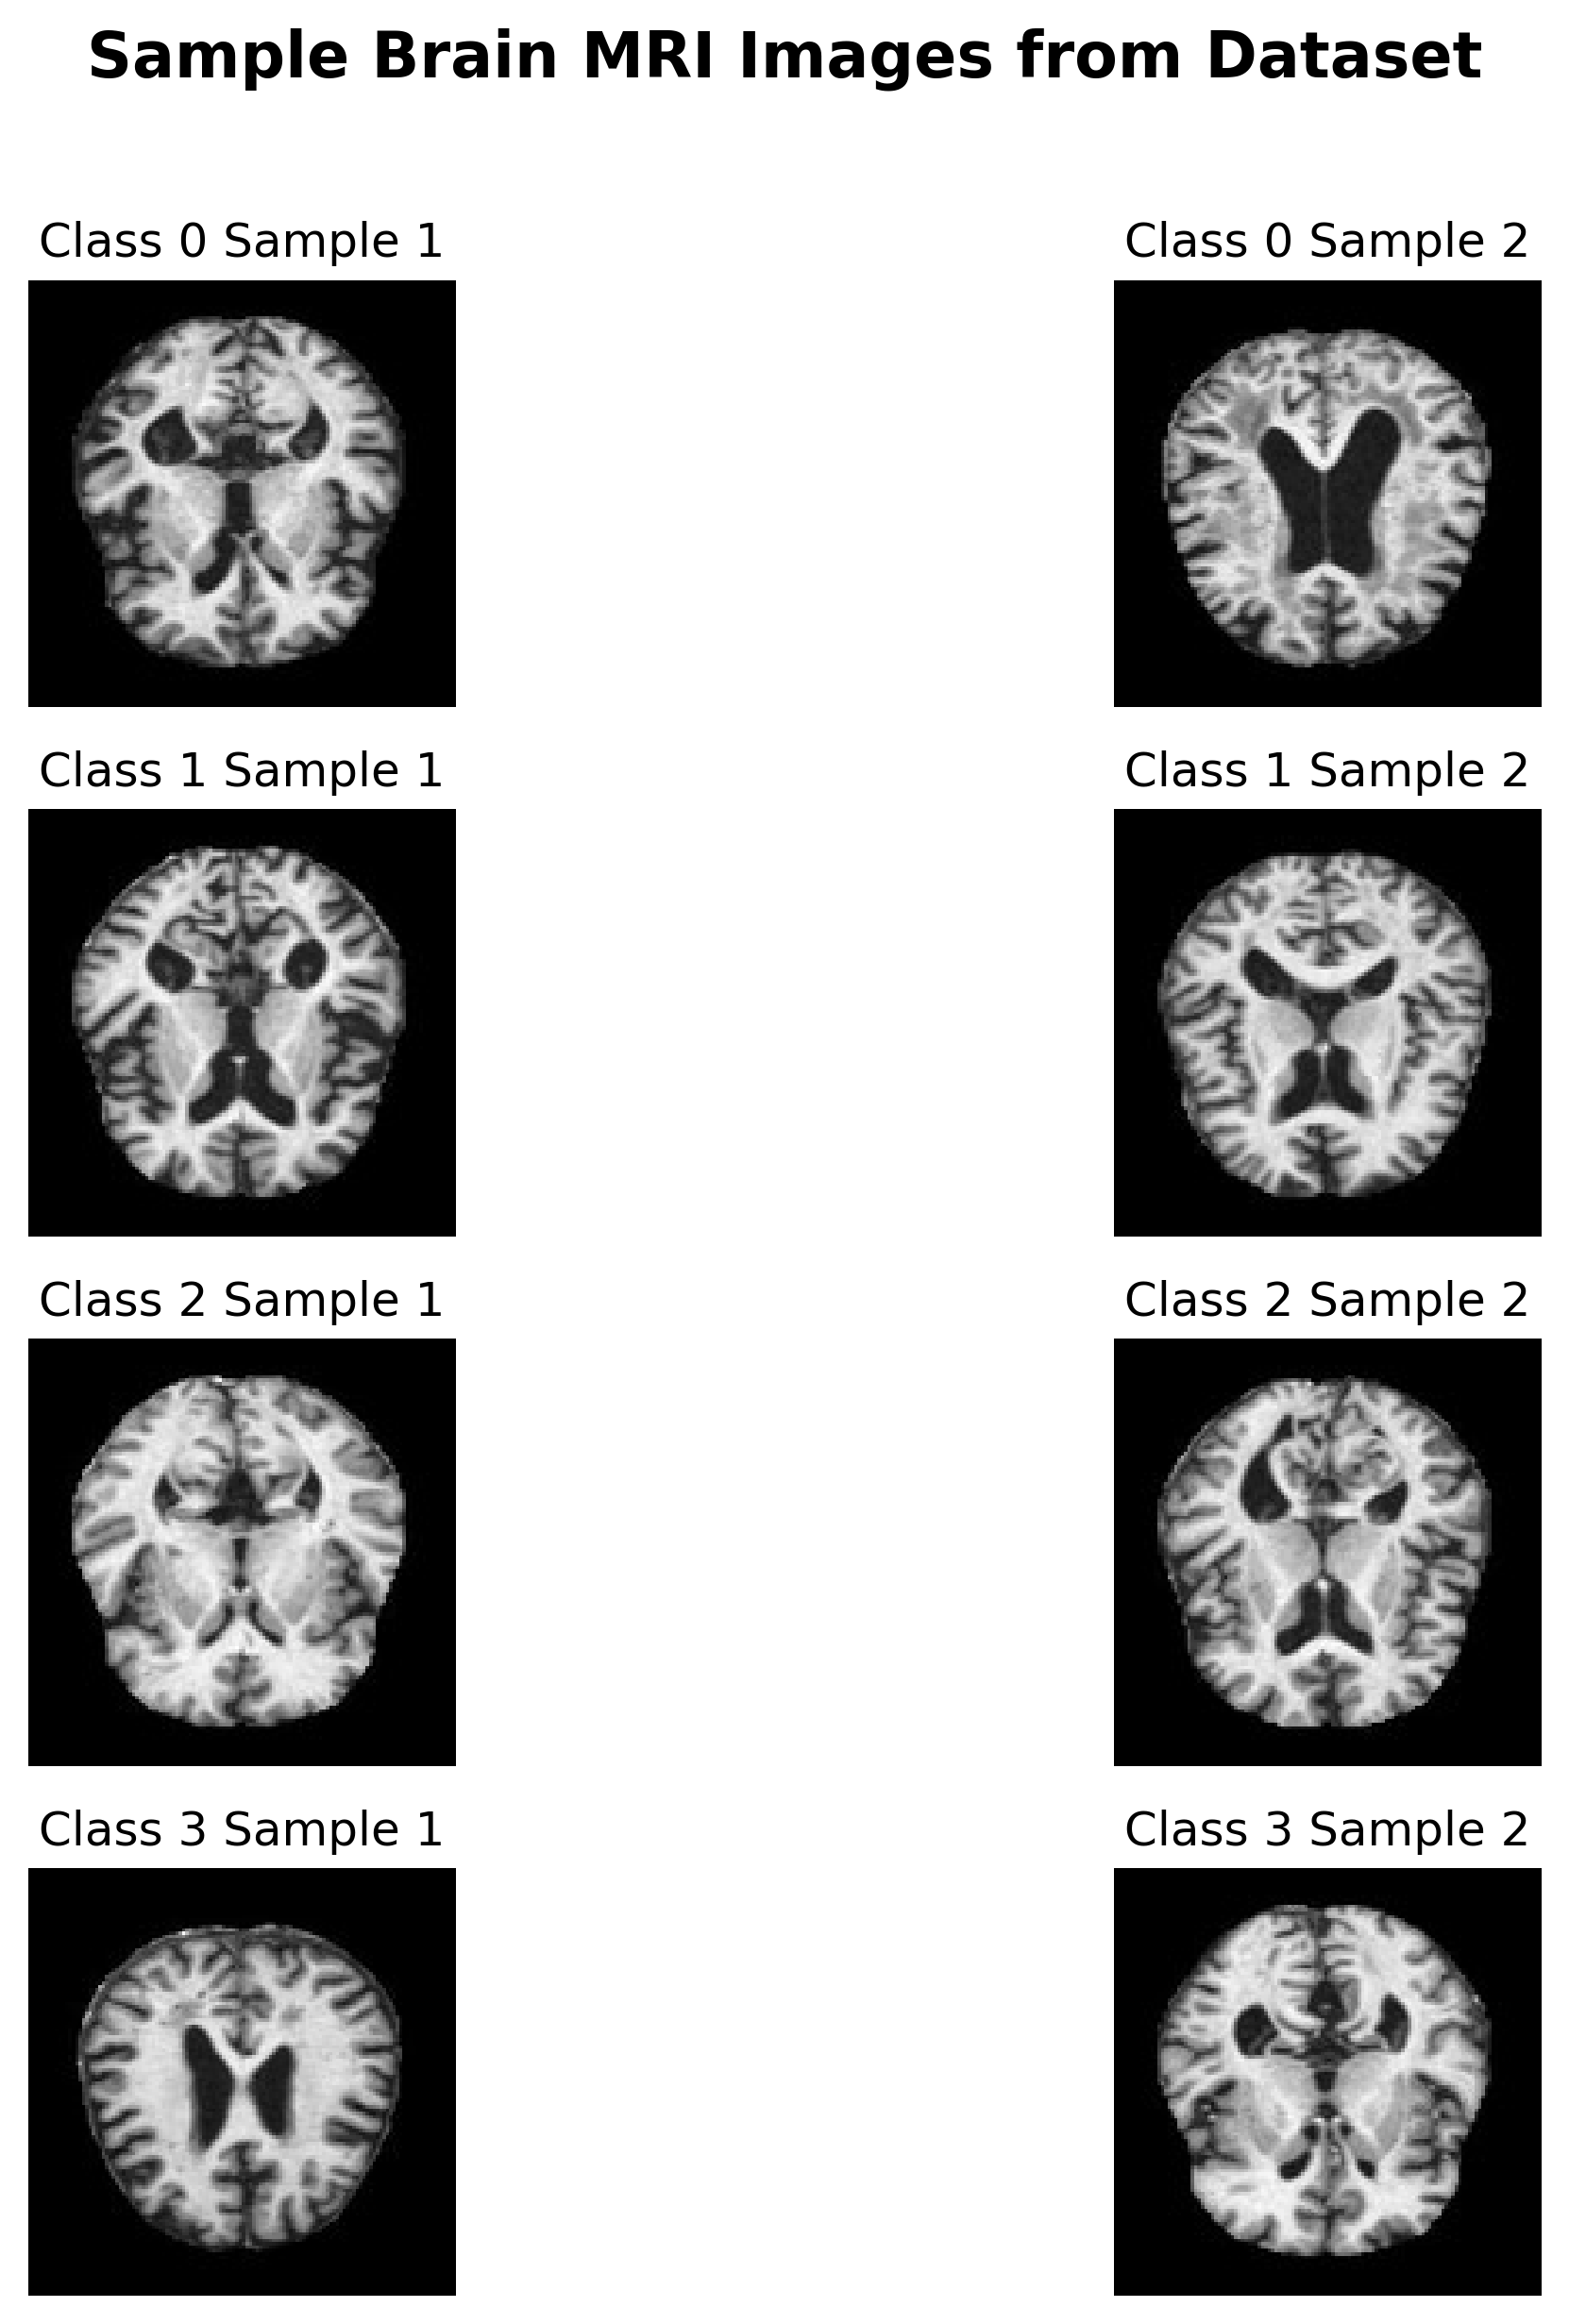

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming `dataset` and `class_names` are already defined from previous steps

def display_sample_images_from_dataset(dataset, class_names, num_samples_per_class=2):
    # Create a dictionary to store one image per class
    samples = {class_name: [] for class_name in class_names}
    samples_found = {class_name: 0 for class_name in class_names}

    # Iterate through the entire unbatched dataset to collect samples until enough are found
    for images, labels in dataset.unbatch():
        label_int = int(labels.numpy())
        class_name = class_names[label_int]
        if samples_found[class_name] < num_samples_per_class:
            samples[class_name].append(images.numpy())
            samples_found[class_name] += 1
        if all(samples_found[cn] == num_samples_per_class for cn in class_names):
            break # Stop if we have enough samples for all classes

    # Now plot the collected samples
    fig, axes = plt.subplots(len(class_names), num_samples_per_class, figsize=(10, 2 * len(class_names)))
    fig.suptitle('Sample Brain MRI Images from Dataset', fontsize=16, fontweight='bold', y=1.02)

    for i, class_name in enumerate(class_names):
        for j in range(num_samples_per_class):
            if samples[class_name]: # Check if samples were found for this class
                img_to_show = samples[class_name][j]
                ax = axes[i, j] if len(class_names) > 1 else axes[j] # Handle single row case
                ax.imshow(img_to_show)
                ax.set_title(f'Class {class_name} Sample {j+1}')
                ax.axis('off')
            else:
                ax = axes[i, j] if len(class_names) > 1 else axes[j] # Handle single row case
                ax.set_title(f'No sample for Class {class_name}')
                ax.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display sample images from the dataset
display_sample_images_from_dataset(dataset, class_names)

In [ ]:
alz_dict = {index: img for index, img in enumerate(class_names)}

class Process:
    def __init__(self, data):
        # Removed redundant normalization as decode_img already normalizes to [0, 1]
        self.data = data

    def create_new_batch(self):
        # Iterate and take the first batch, ensuring it's unbatched before mapping for consistency
        # Then batch it again, but keep it as a tf.Tensor or numpy array for processing
        for images, labels in self.data.take(1):
            self.batch = (images.numpy(), labels.numpy())

        text = "Min and max pixel values in the batch ->"
        print(text, self.batch[0].min(), "&", self.batch[0].max())

    def show_batch_images(self, number_of_images=5):
        fig, ax = plt.subplots(ncols=number_of_images, figsize=(20,20), facecolor="gray")
        fig.suptitle("Brain MRI (Alzheimer) Samples in the Batch", color="yellow",fontsize=18, fontweight='bold', y=0.6)
        for idx, img in enumerate(self.batch[0][:number_of_images]):
            ax[idx].imshow(img)
            class_no = self.batch[1][idx]
            ax[idx].set_title(alz_dict[class_no], color="aqua")
            ax[idx].set_xticklabels([])
            ax[idx].set_yticklabels([])

    def train_test_val_split(self, train_size, val_size, test_size):
        total_batches = tf.data.experimental.cardinality(self.data).numpy()

        train_batches = int(total_batches * train_size)
        val_batches = int(total_batches * val_size)
        test_batches = total_batches - train_batches - val_batches # Ensure all batches are covered

        train_data = self.data.take(train_batches)
        val_data = self.data.skip(train_batches).take(val_batches)
        test_data = self.data.skip(train_batches + val_batches).take(test_batches)

        return train_data, val_data, test_data

Min and max pixel values in the batch -> 0.0 & 1.0


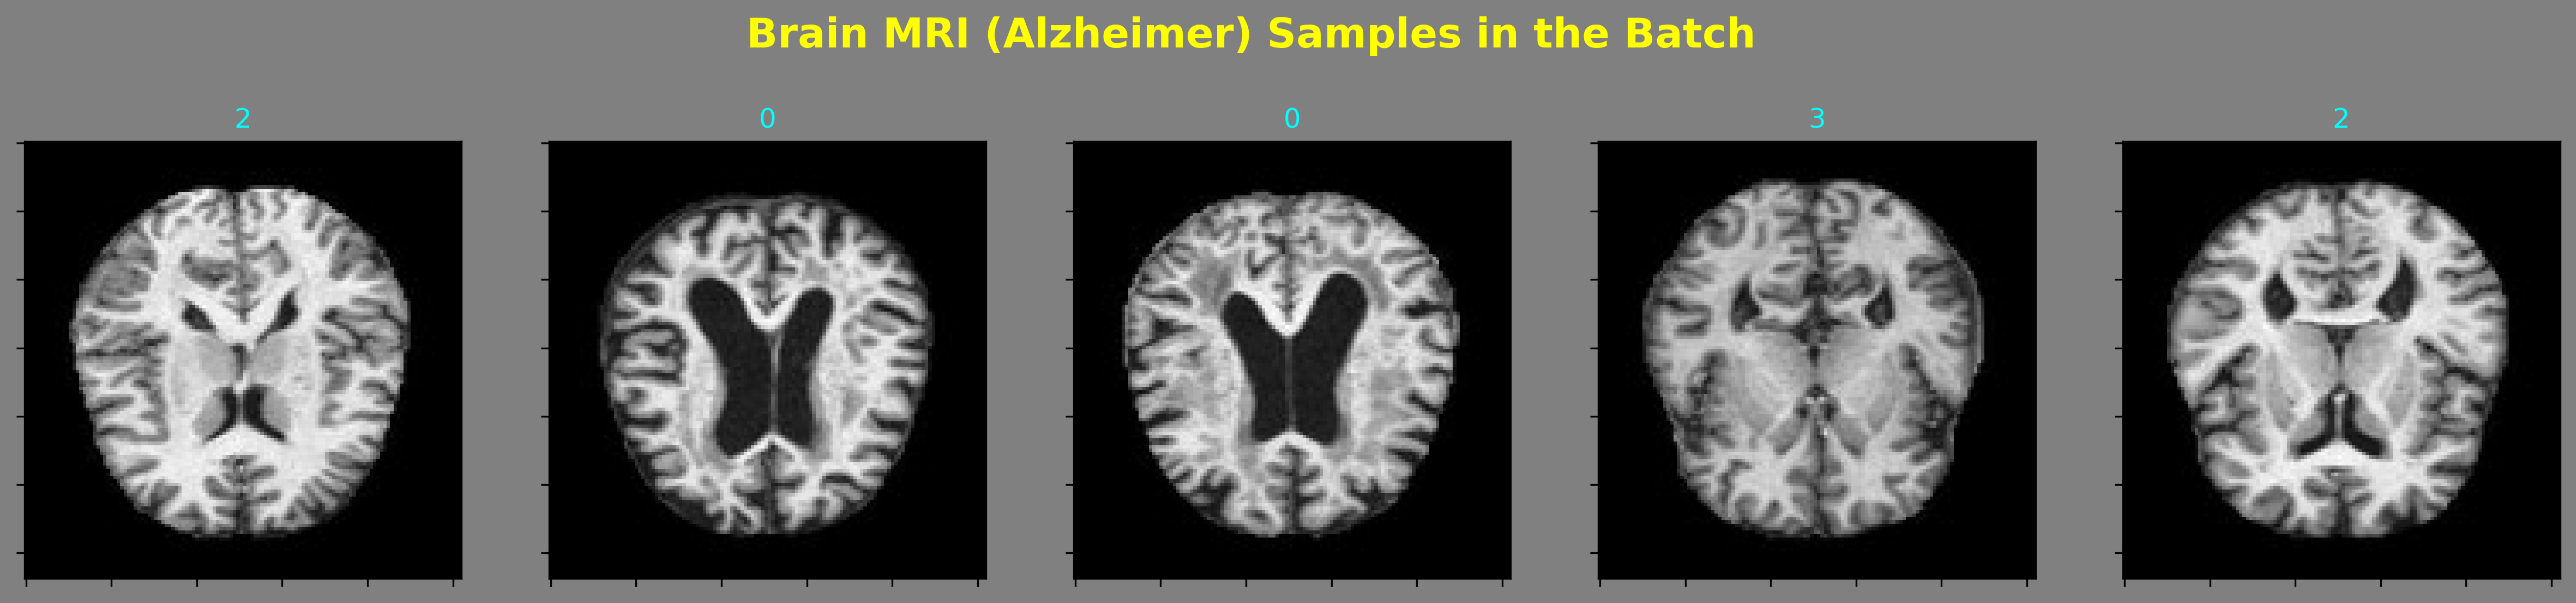

In [ ]:
process = Process(dataset)
process.create_new_batch()
process.show_batch_images(number_of_images=5)

In [ ]:
train_data, val_data, test_data= process.train_test_val_split(train_size=0.8, val_size=0.1, test_size=0.1)

In [ ]:
y_train = tf.concat(list(map(lambda x: x[1], train_data)), axis=0)
class_weight = compute_class_weight('balanced',classes=np.unique(y_train), y=y_train.numpy())
class_weights = dict(zip(np.unique(y_train), class_weight))

In [ ]:
def build_model():
    model = Sequential()

    model.add(Conv2D(filters=16, kernel_size=(3, 3), strides=(1, 1), activation="relu", kernel_initializer='he_normal',
                     input_shape=(128, 128, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), activation="relu", kernel_initializer='he_normal'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), activation="relu", kernel_initializer='he_normal'))
    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(Flatten())
    model.add(Dense(128, activation="relu", kernel_initializer='he_normal'))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(4, activation="softmax"))

    model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])

    model.summary()

    return model

model = build_model()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,261,988 (12.44 MB)

 Trainable params: 3,261,988 (12.44 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def checkpoint_callback():

    checkpoint_filepath = '/tmp/checkpoint.keras'

    model_checkpoint_callback= ModelCheckpoint(filepath=checkpoint_filepath,
                           save_weights_only=False,
                           save_freq='epoch',
                           monitor='val_accuracy',
                           save_best_only=True,
                           verbose=1)

    return model_checkpoint_callback

def early_stopping(patience):
    es_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, verbose=1)
    return es_callback


EPOCHS = 20
checkpoint_callback = checkpoint_callback()
early_stopping = early_stopping(patience=5)
callbacks = [checkpoint_callback, early_stopping]

In [ ]:
history = model.fit(train_data, epochs = EPOCHS, validation_data = val_data, class_weight = class_weights, callbacks = callbacks)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.2809 - loss: 2.7357
Epoch 1: val_accuracy improved from None to 0.28906, saving model to /tmp/checkpoint.keras

Epoch 1: finished saving model to /tmp/checkpoint.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 90s 533ms/step - accuracy: 0.2998 - loss: 1.7513 - val_accuracy: 0.2891 - val_loss: 1.3507
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.4330 - loss: 1.3430
Epoch 2: val_accuracy improved from 0.28906 to 0.31875, saving model to /tmp/checkpoint.keras

Epoch 2: finished saving model to /tmp/checkpoint.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 84s 521ms/step - accuracy: 0.4643 - loss: 1.2062 - val_accuracy: 0.3187 - val_loss: 1.4074
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.5546 - loss: 0.9077
Epoch 3: val_accuracy improved from 0.31875 to 0.54219, saving model to /tmp/checkpoint.keras

Epoch 3: finished saving model to /tmp/checkpoint.keras
160/160 ━━━━━━━━━━━━━━━━━━━━ 141s 517ms/step -

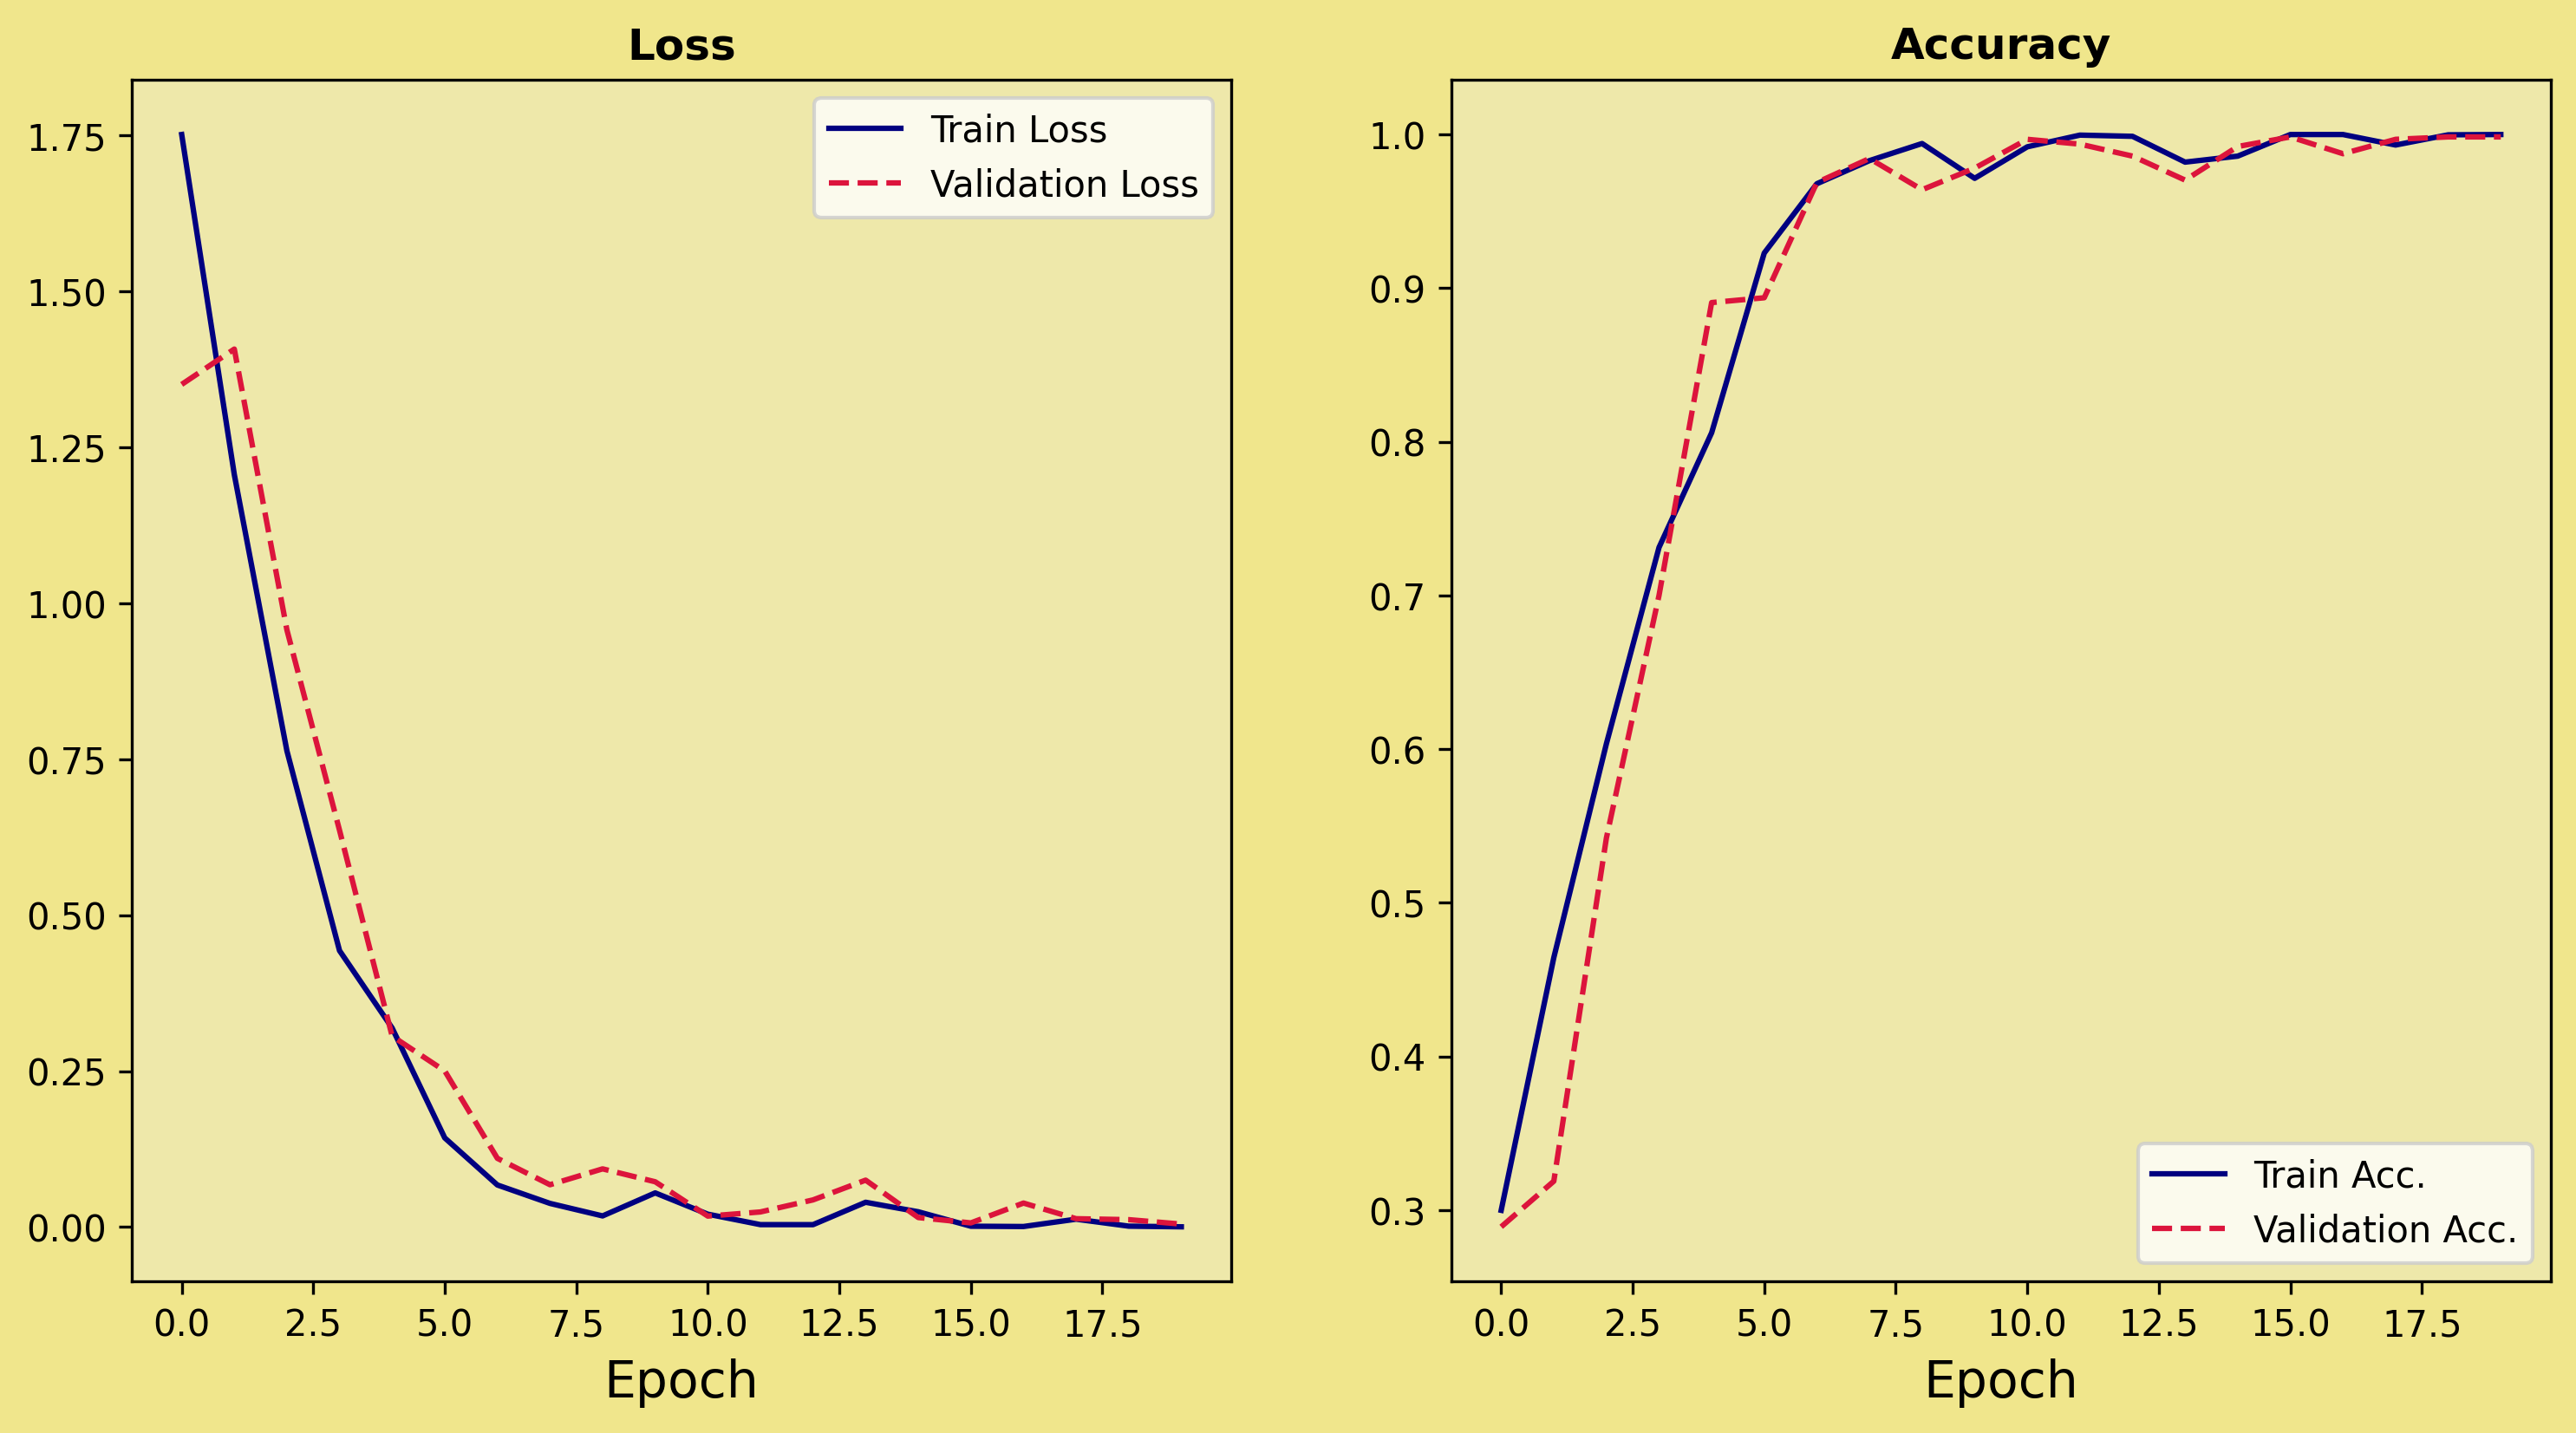

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,6), facecolor="khaki")
ax[0].set_facecolor('palegoldenrod')
ax[0].set_title('Loss', fontweight="bold")
ax[0].set_xlabel("Epoch", size=14)
ax[0].plot(history.epoch, history.history["loss"], label="Train Loss", color="navy")
ax[0].plot(history.epoch, history.history["val_loss"], label="Validation Loss", color="crimson", linestyle="dashed")
ax[0].legend()
ax[1].set_facecolor('palegoldenrod')
ax[1].set_title('Accuracy', fontweight="bold")
ax[1].set_xlabel("Epoch", size=14)
ax[1].plot(history.epoch, history.history["accuracy"], label="Train Acc.", color="navy")
ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation Acc.", color="crimson", linestyle="dashed")
ax[1].legend()

In [ ]:
model.evaluate(test_data)

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 247ms/step - accuracy: 0.9953 - loss: 0.0123


[0.012286640703678131, 0.995312511920929]

In [ ]:
predictions = []
labels = []

for X, y in test_data.as_numpy_iterator():
    y_pred = model.predict(X, verbose=0)
    y_prediction = np.argmax(y_pred, axis=1)
    predictions.extend(y_prediction)
    labels.extend(y)

predictions = np.array(predictions)
labels = np.array(labels)

print(classification_report(labels, predictions, target_names=class_names))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00       321
           3       1.00      1.00      1.00       231

    accuracy                           1.00       640
   macro avg       1.00      1.00      1.00       640
weighted avg       1.00      1.00      1.00       640



Text(287.16666666666663, 0.5, 'True')

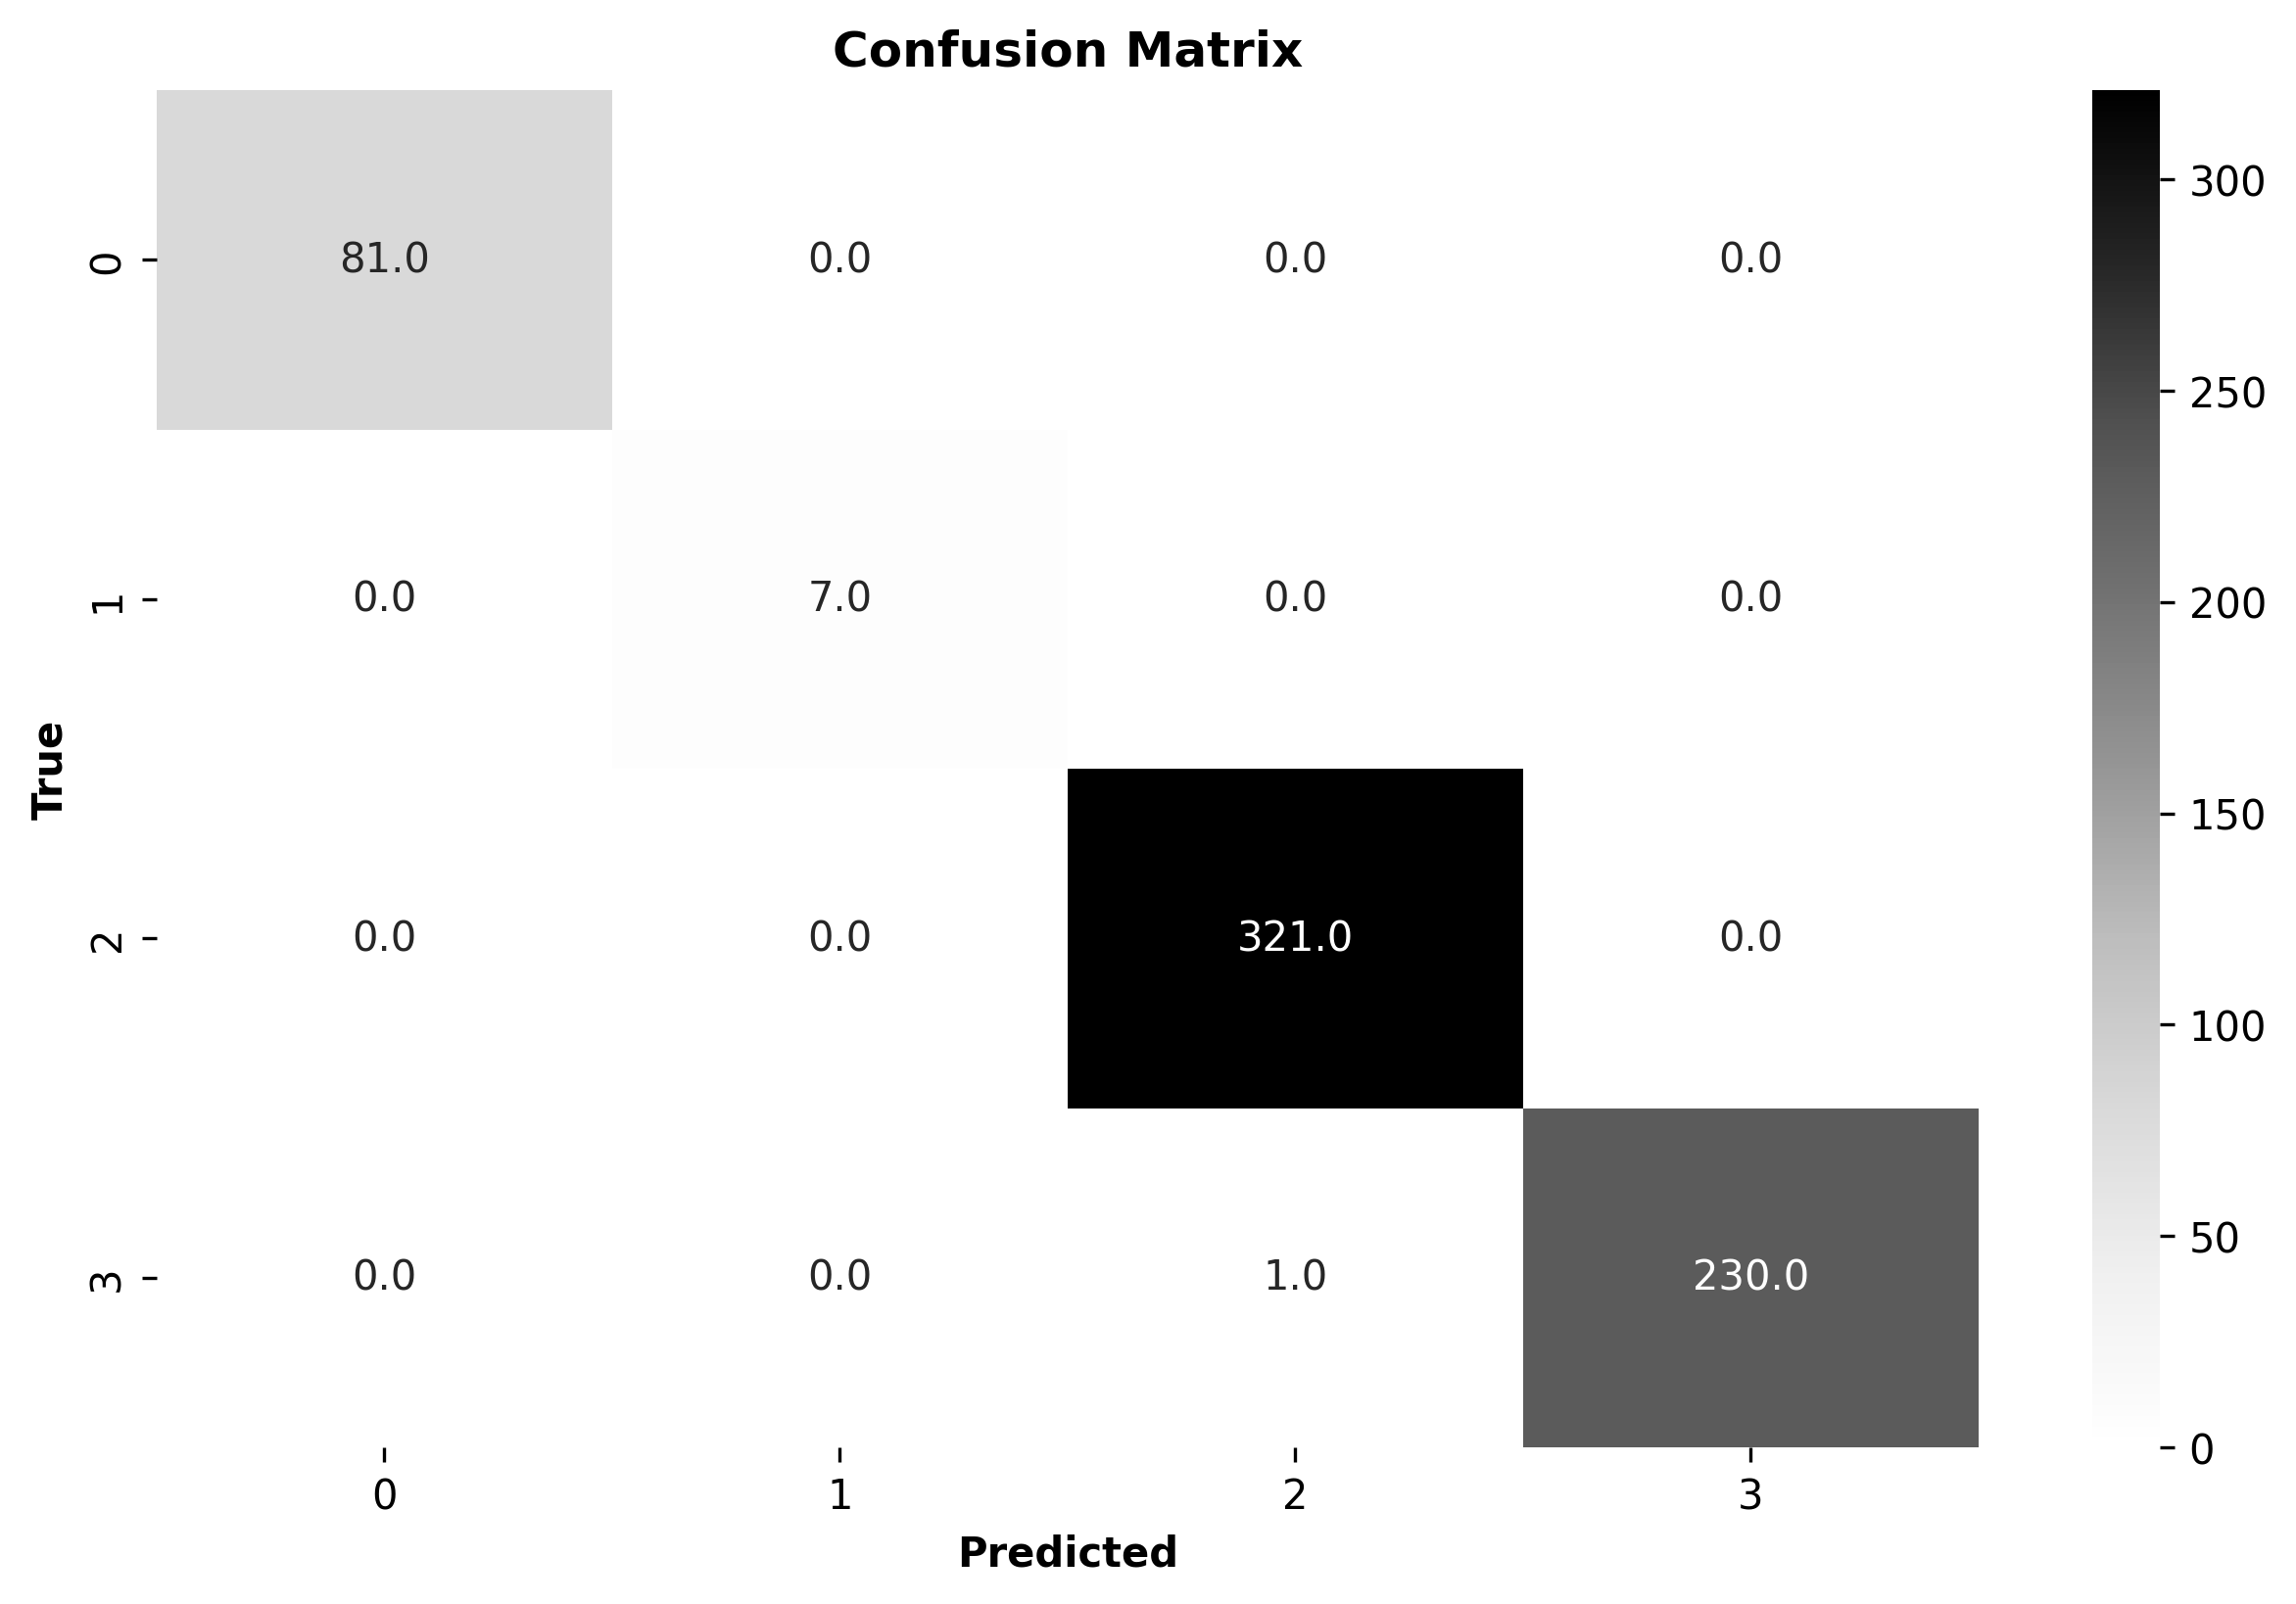

In [ ]:
cm = confusion_matrix(labels, predictions)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df
plt.figure(figsize=(10,6), dpi=300)
sns.heatmap(cm_df, annot=True, cmap="Greys", fmt=".1f")
plt.title("Confusion Matrix", fontweight="bold")
plt.xlabel("Predicted", fontweight="bold")
plt.ylabel("True", fontweight="bold")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


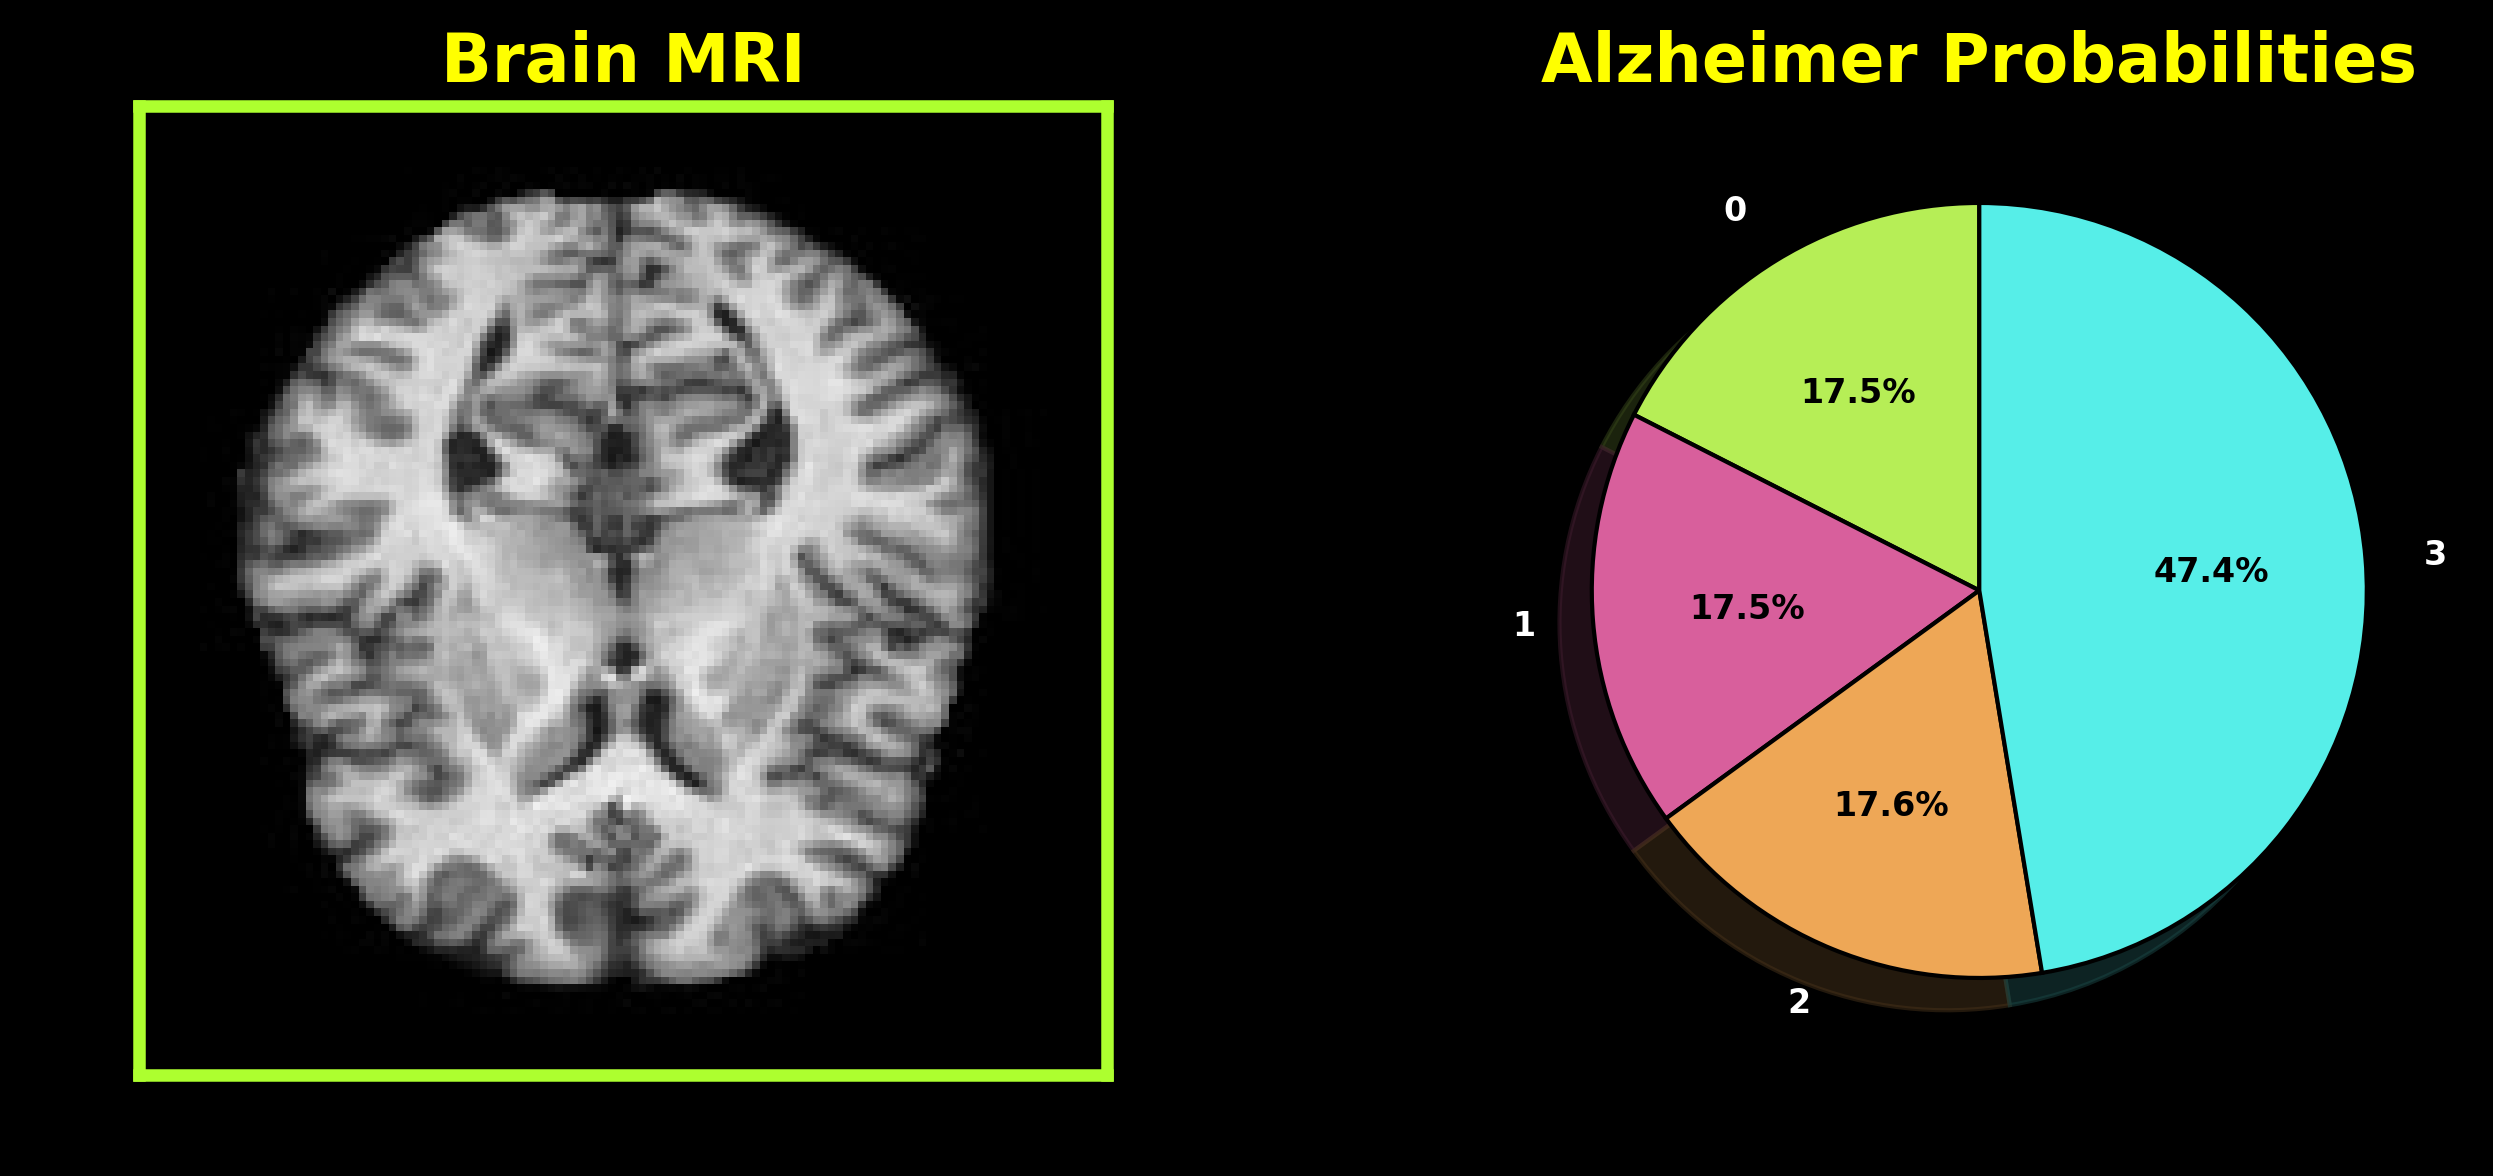

In [ ]:
def random_mri_prob_bringer(image_number=0):

    for images, _ in test_data.skip(5).take(1):
        image = images[image_number]
        pred = model.predict(tf.expand_dims(image, 0))[0]

    probs = list(tf.nn.softmax(pred).numpy())
    probs_dict = dict(zip(class_names, probs)) # Changed class_dist.keys() to class_names

    keys = list(probs_dict.keys())
    values = list(probs_dict.values())

    fig, (ax1, ax2) = plt.subplots(1, 2, facecolor='black')
    plt.subplots_adjust(wspace=0.4)
    ax1.imshow(image)
    ax1.set_title('Brain MRI', color="yellow", fontweight="bold", fontsize=16)

    edges = ['left', 'bottom', 'right', 'top']
    edge_color = "greenyellow"
    edge_width = 3
    for edge in edges:
        ax1.spines[edge].set_linewidth(edge_width)
        ax1.spines[edge].set_edgecolor(edge_color)

    plt.gca().axes.yaxis.set_ticklabels([])
    plt.gca().axes.xaxis.set_ticklabels([])

    wedges, labels, autopct = ax2.pie(values, labels=keys,  autopct='%1.1f%%',
        shadow=True, startangle=90, colors=colors, textprops={'fontsize': 8, "fontweight":"bold", "color":"white"},  wedgeprops=
       {'edgecolor':'black'} , labeldistance=1.15)

    for autotext in autopct:
        autotext.set_color('black')

    ax2.set_title('Alzheimer Probabilities', color="yellow", fontweight="bold", fontsize=16)

rand_img_no = np.random.randint(1, 32)
random_mri_prob_bringer(image_number=rand_img_no)

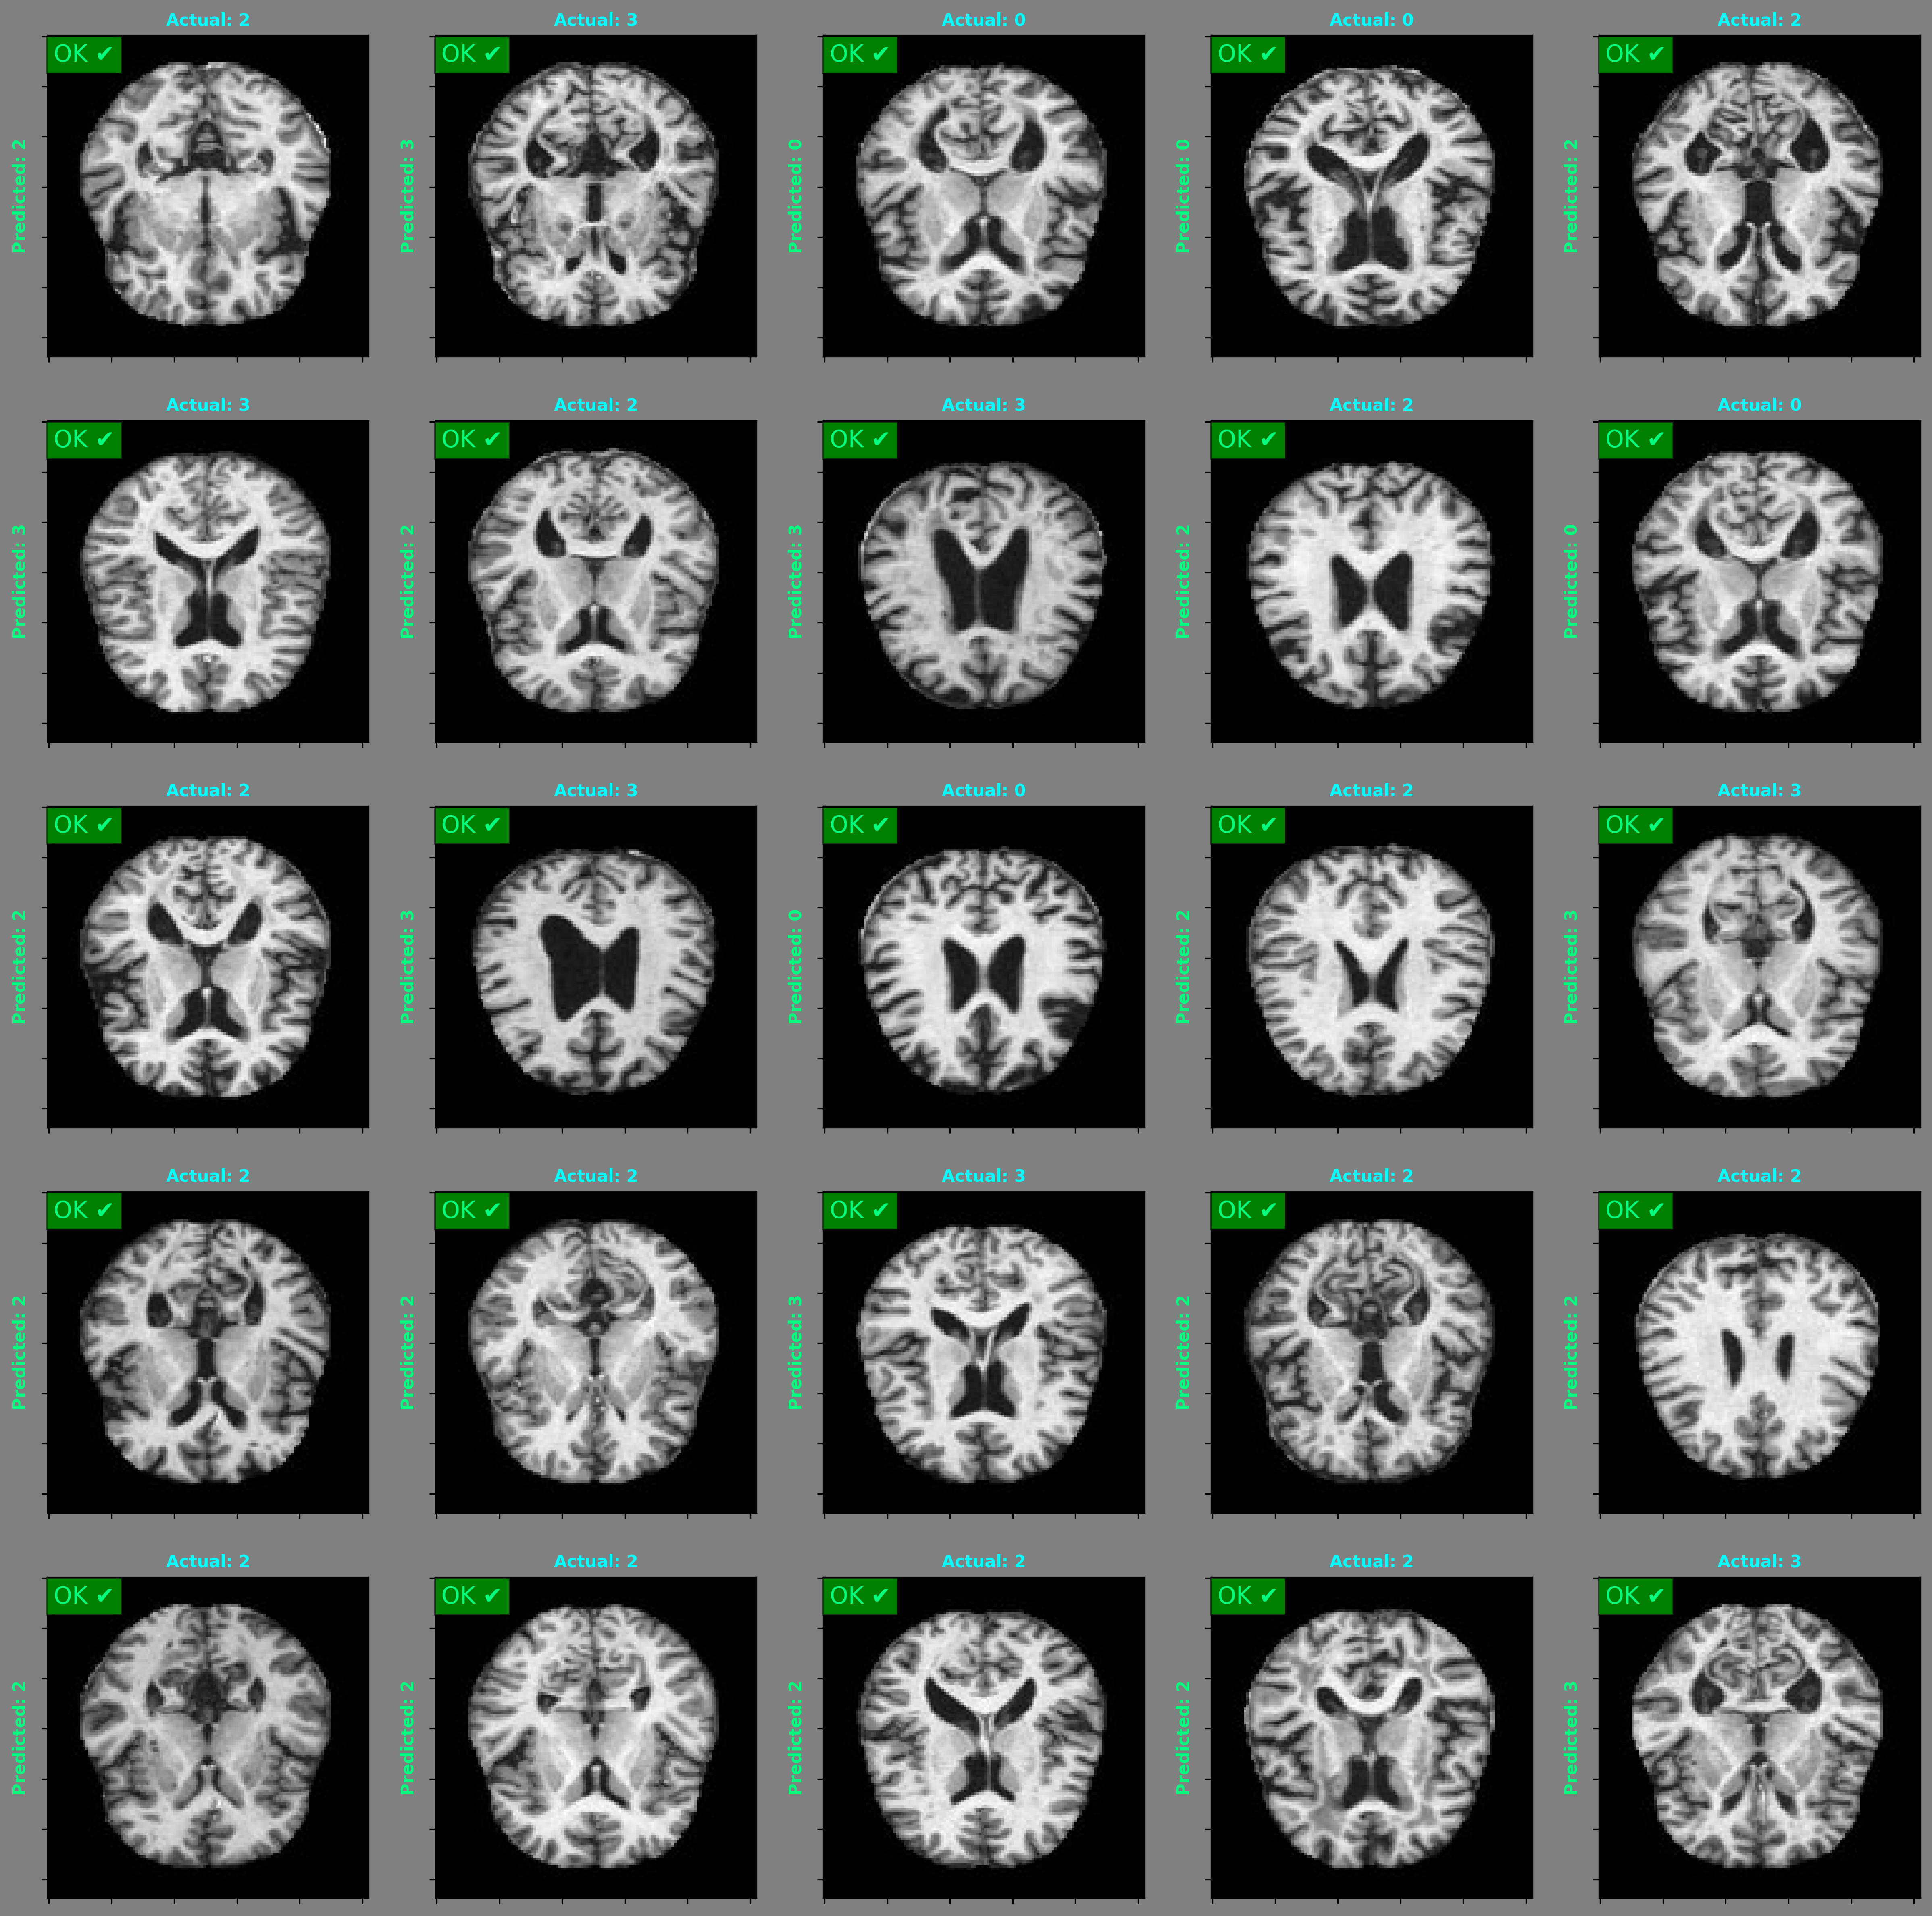

In [38]:
plt.figure(figsize=(20, 20), facecolor="gray")
for images, labels in test_data.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])
        predictions = model.predict(tf.expand_dims(images[i], 0), verbose=0)
        score = tf.nn.softmax(predictions[0])
        if(class_names[labels[i]]==class_names[np.argmax(score)]):
            plt.title("Actual: "+class_names[labels[i]], color="aqua", fontweight="bold", fontsize=10)
            plt.ylabel("Predicted: "+class_names[np.argmax(score)], color="springgreen", fontweight="bold", fontsize=10)
            ok_text = plt.text(2, 10, "OK \u2714", color="springgreen", fontsize=14)
            ok_text.set_bbox(dict(facecolor='lime', alpha=0.5))

        else:
            plt.title("Actual: "+class_names[labels[i]], color="aqua", fontweight="bold", fontsize=10)
            plt.ylabel("Predicted: "+class_names[np.argmax(score)], color="maroon", fontweight="bold", fontsize=10)
            nok_text = plt.text(2, 10, "NOK \u2718", color="red", fontsize=14)
            nok_text.set_bbox(dict(facecolor='maroon', alpha=0.5))
        plt.gca().axes.yaxis.set_ticklabels([])
        plt.gca().axes.xaxis.set_ticklabels([])

In [39]:
total_samples = np.sum(cm)
correct_predictions = np.sum(np.diag(cm))

exact_accuracy = correct_predictions / total_samples

print(f"Total samples in test data: {total_samples}")
print(f"Correct predictions from confusion matrix: {correct_predictions}")
print(f"Exact test accuracy from confusion matrix: {exact_accuracy:.4f}")


Total samples in test data: 640
Correct predictions from confusion matrix: 639
Exact test accuracy from confusion matrix: 0.9984


As you can see, the exact accuracy from the confusion matrix is slightly less than 100%. The output from `model.evaluate` was likely rounded to 1.00.

Now, let's proceed with a more thorough check of the notebook from the beginning to address your concern about the justification of this high accuracy. We'll start by looking at the dataset characteristics again.

In [40]:
print('Combined dataset shape:', combined_dataset.shape)
print('Class distribution in the combined dataset:')
display(label_counts)

# Let's also look at the shape of the individual train, validation, and test datasets.
print(f"Number of batches in training data: {tf.data.experimental.cardinality(train_data).numpy()}")
print(f"Number of batches in validation data: {tf.data.experimental.cardinality(val_data).numpy()}")
print(f"Number of batches in test data: {tf.data.experimental.cardinality(test_data).numpy()}")

# Calculate total samples in each split (assuming BATCH_SIZE is defined and consistent)
print(f"Number of samples in training data: {tf.data.experimental.cardinality(train_data).numpy() * BATCH_SIZE}")
print(f"Number of samples in validation data: {tf.data.experimental.cardinality(val_data).numpy() * BATCH_SIZE}")
print(f"Number of samples in test data: {tf.data.experimental.cardinality(test_data).numpy() * BATCH_SIZE}")


Combined dataset shape: (6400, 2)
Class distribution in the combined dataset:


,count
label,
0,896
1,64
2,3200
3,2240


Number of batches in training data: 160
Number of batches in validation data: 20
Number of batches in test data: 20
Number of samples in training data: 5120
Number of samples in validation data: 640
Number of samples in test data: 640


The class distribution shows a significant imbalance, with class '2' having the most samples and class '1' having the fewest. While `class_weights` were used during training to mitigate this, it's a factor to consider. The splits also appear to be consistent with the requested 80/10/10 ratio.

Next, let's review the model architecture and training history for signs of overfitting or other issues.

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,785,966 (37.33 MB)

 Trainable params: 3,261,988 (12.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,523,978 (24.89 MB)

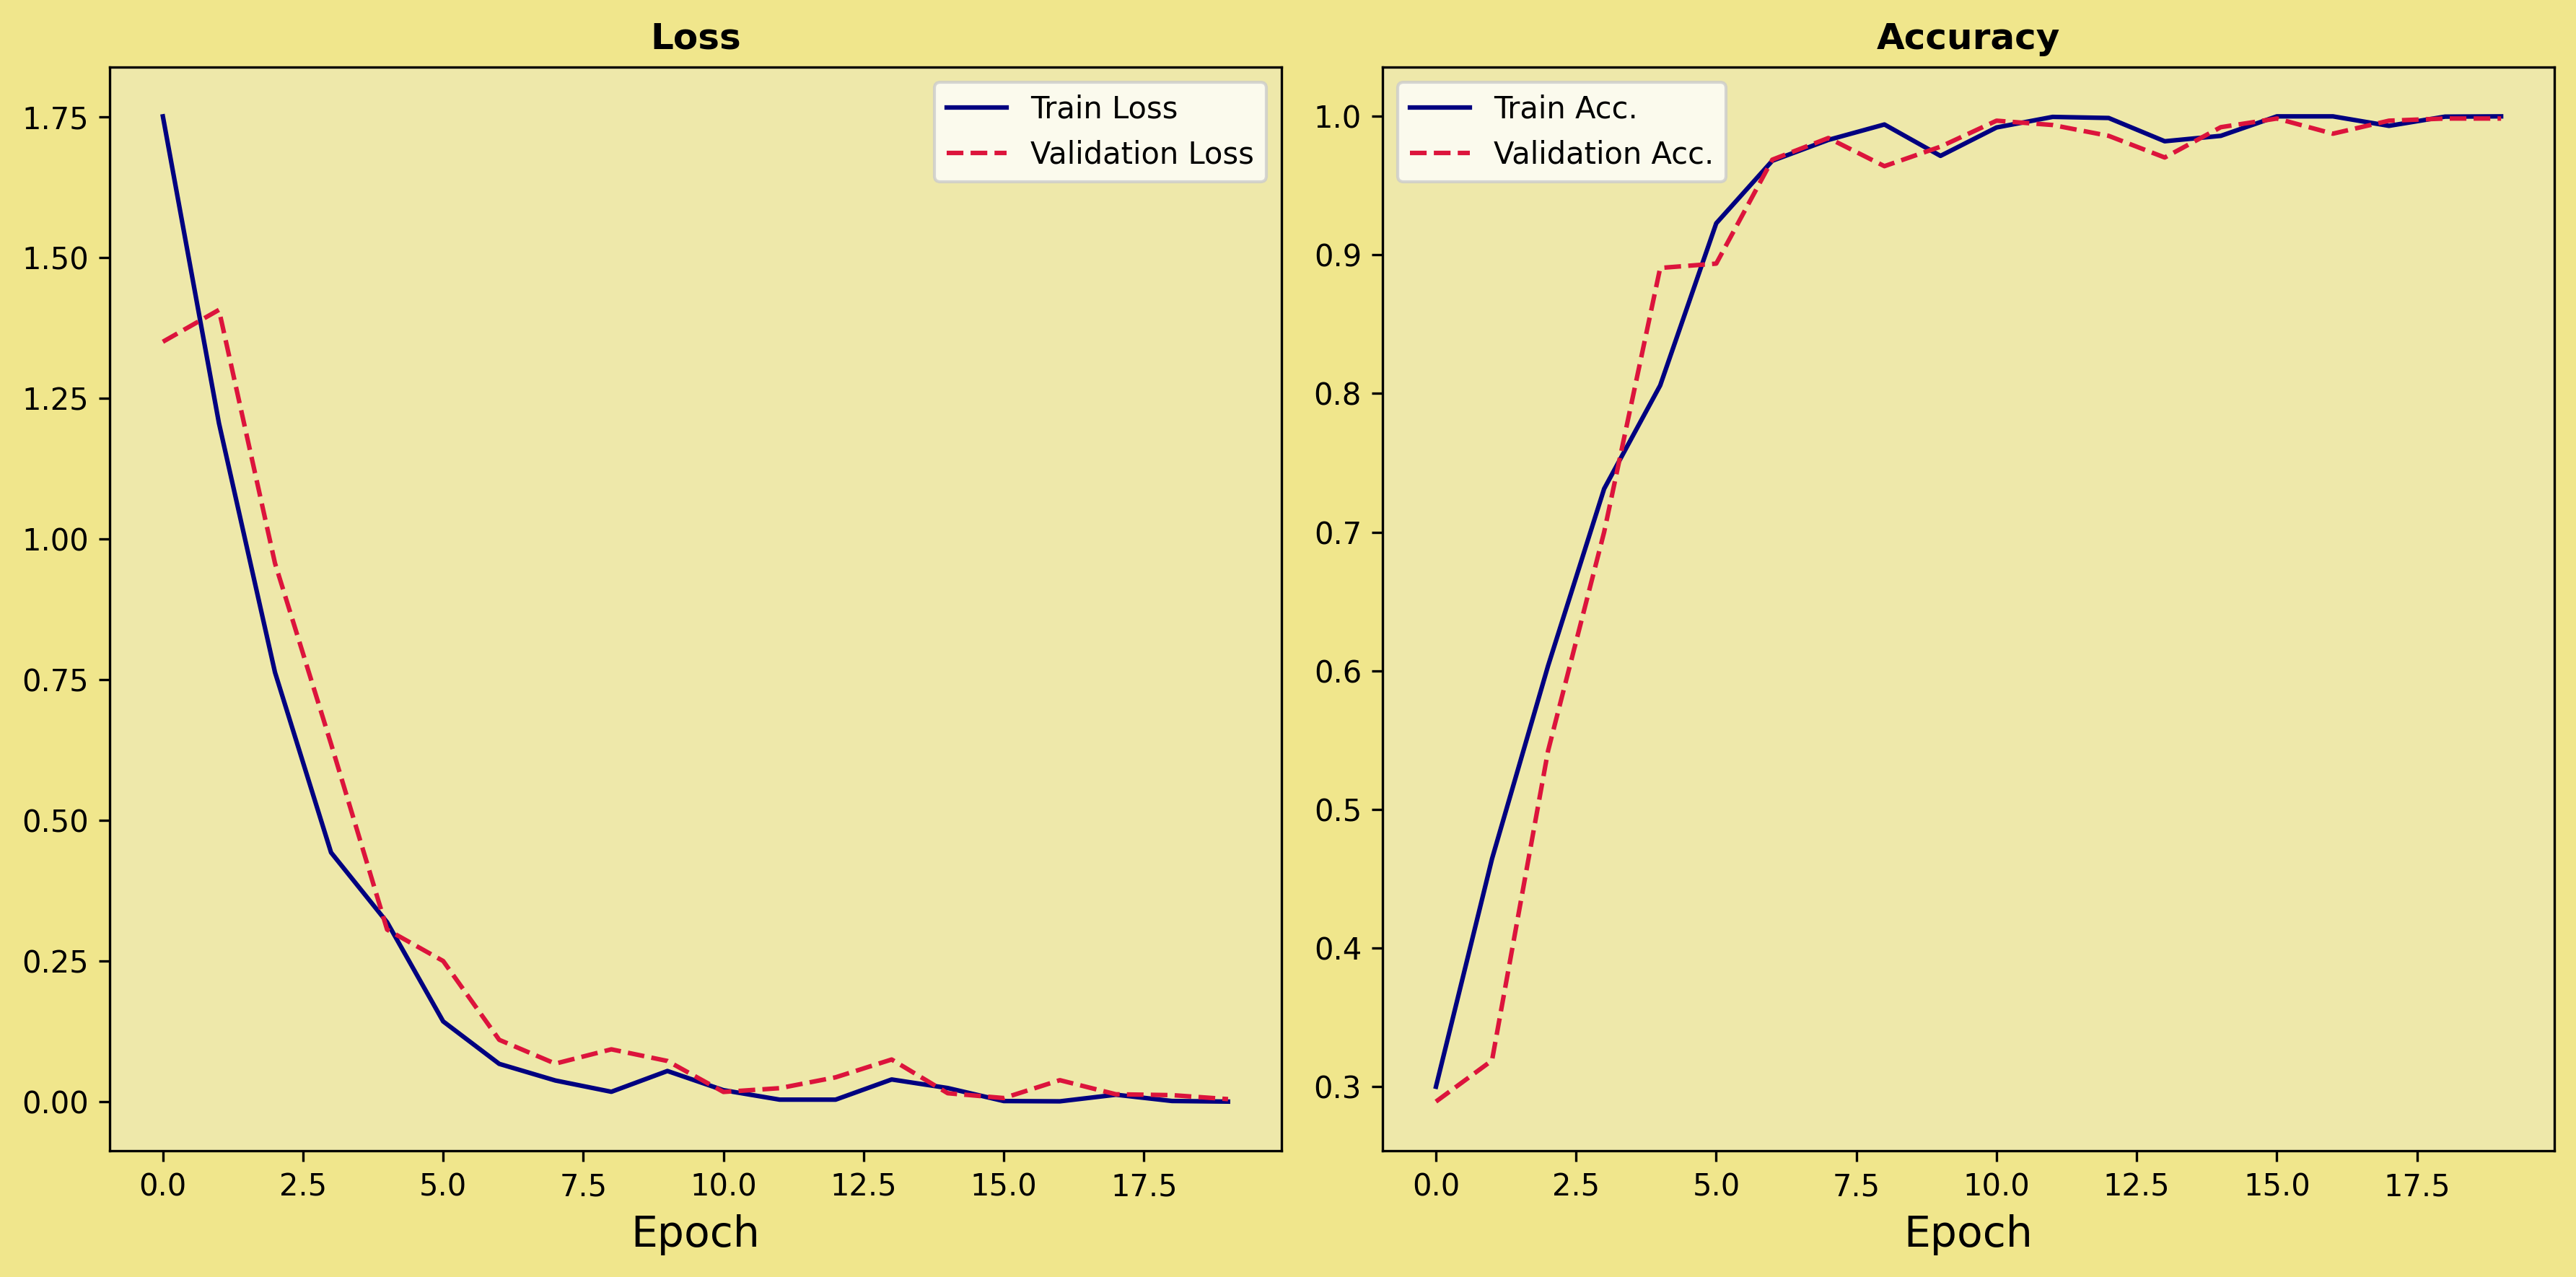

In [41]:
model.summary()

# Plotting training and validation metrics again for review
fig, ax = plt.subplots(1, 2, figsize=(12,6), facecolor="khaki")
ax[0].set_facecolor('palegoldenrod')
ax[0].set_title('Loss', fontweight="bold")
ax[0].set_xlabel("Epoch", size=14)
ax[0].plot(history.epoch, history.history["loss"], label="Train Loss", color="navy")
ax[0].plot(history.epoch, history.history["val_loss"], label="Validation Loss", color="crimson", linestyle="dashed")
ax[0].legend()
ax[1].set_facecolor('palegoldenrod')
ax[1].set_title('Accuracy', fontweight="bold")
ax[1].set_xlabel("Epoch", size=14)
ax[1].plot(history.epoch, history.history["accuracy"], label="Train Acc.", color="navy")
ax[1].plot(history.epoch, history.history["val_accuracy"], label="Validation Acc.", color="crimson", linestyle="dashed")
ax[1].legend()
plt.tight_layout()
plt.show()
